In [22]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *
circle = Hypersphere(1)

# Set Parameters

In [23]:
n_samples = 1000
sigma2 = .05

# densitiy estimation
M = 3
rho = 1e-2

# prior param
num_modes = 3
tau2 = 0.05
G_params = {'tau2': tau2, 'num_modes': num_modes} 


In [24]:
Theta = S1_multimodal_prior(n_samples, G_params)
X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
delta = denoiser('S1', X, M, rho, sigma2, X)

# Visualisation

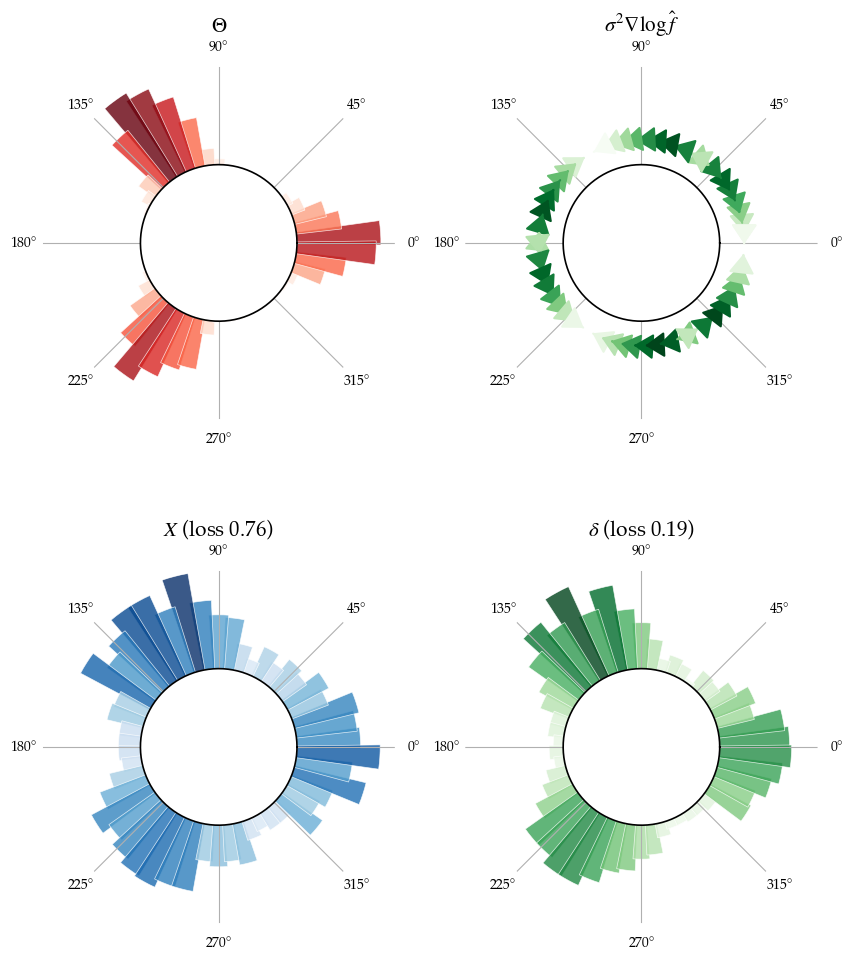

In [25]:
fig, axs = plt.subplots(2,2, figsize = (10,12), subplot_kw={'polar':True})

nbins = 50
S1_histogram(Theta, nbins, axs[0,0], 'Reds')
S1_histogram(X, nbins, axs[1,0], 'Blues')
S1_histogram(delta, nbins, axs[1,1], 'Greens')

S1_score_quiver(X, M, rho, axs[0,1], res = 50)

loss_N = (circle.metric.dist_broadcast(X, Theta)*2).mean()
loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean()      
axs[0,0].set_title('$\Theta$', fontsize = 15)
axs[1,0].set_title('$X$ (loss {:.2f})'.format(loss_N), fontsize = 15)
axs[1,1].set_title('$\delta$ (loss {:.2f})'.format(loss_T), fontsize = 15)
axs[0,1].set_title(r'$\sigma^2 \nabla \log \hat{f}$', fontsize = 15)




plt.show()


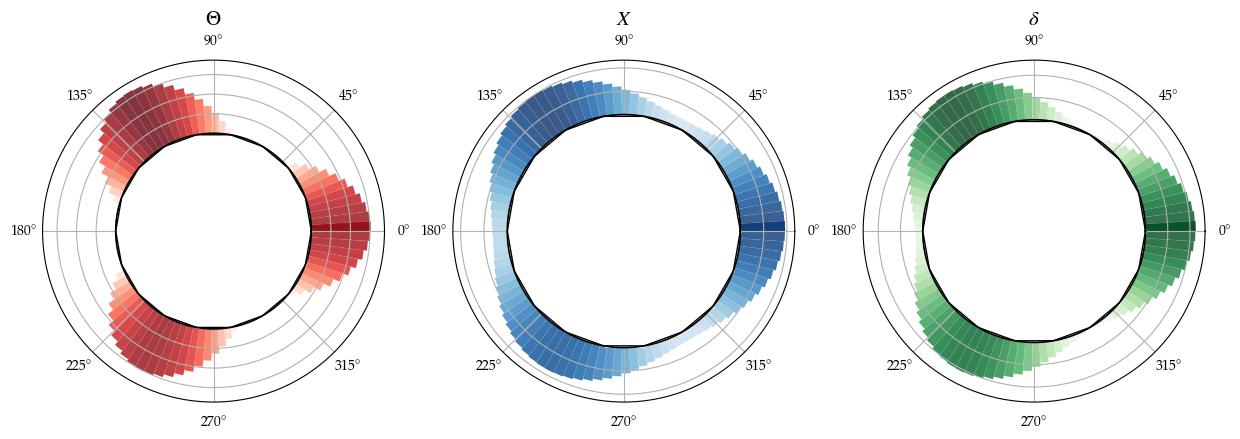

In [5]:
fig, axs = plt.subplots(1,3, figsize = (15,5), subplot_kw={'polar':True})
nbins = 50
S1_smooth_histogram(Theta, M, axs[0], 'Reds')
S1_smooth_histogram(X, M, axs[1], 'Blues')
S1_smooth_histogram(delta, M, axs[2], 'Greens')
for ax,title in zip(axs, ['$\Theta$', '$X$', '$\delta$']):
    ax.set_title(title, fontsize = 15)
plt.show()


# Monte Carlo estimate of Naive and Denoised Risk

σ²=0.75: 100%|██████████| 20/20 [00:07<00:00,  2.86it/s]
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


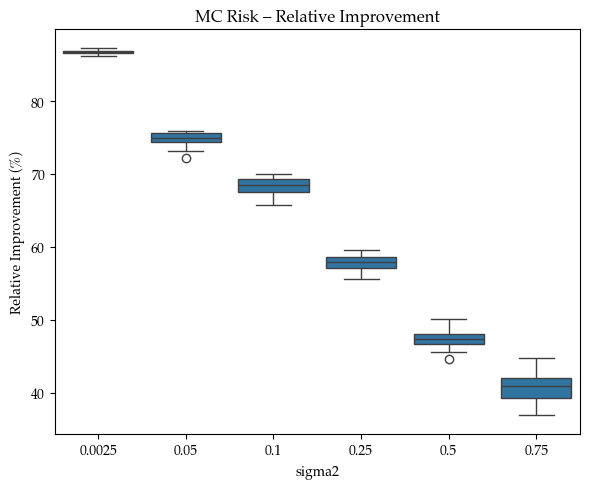

In [ ]:
tau2 = 0.05

n_samples = 1000
rho = 1e-2
M = 3
NMC = 20

all_num_modes =  [1, 2, 3, 4]
def MCrun(n, sigma2, M, rho, G_params):
    circle = Hypersphere(1)
    Theta = S1_multimodal_prior(n_samples, G_params)
    X = circle.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
    delta = denoiser('S1', X, M, rho, sigma2, X)
    loss_N = (circle.metric.dist_broadcast(X, Theta)**2).mean()  # Fixed: was *2 instead of **2
    loss_T = (circle.metric.dist_broadcast(delta, Theta)**2).mean()      
    return loss_T, loss_N


all_records = []  # Collect all data across num_modes

for num_modes in all_num_modes:
    G_params = {'tau2': tau2, 'num_modes': num_modes} 
    sigma2s = [0.0025, 0.05, .1, .25, .5, .75]
    
    for sigma2 in sigma2s:
        ratios = []
        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}'):
            loss_T, loss_N = MCrun(n_samples, sigma2, M, rho, G_params)
            ratios.append(((loss_N - loss_T) / loss_N) * 100)
        
        all_records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "sigma2": [sigma2] * NMC,
            "Relative Improvement (%)": ratios
        }))

df = pd.concat(all_records, ignore_index=True)

# Create subplots for each num_modes
fig, axs = plt.subplots(2, len(num_modes), figsize=(12, 10))

for idx, num_modes in enumerate(all_num_modes):
    df_subset = df[df['num_modes'] == num_modes]
    sns.boxplot(data=df_subset, x="sigma2", y="Relative Improvement (%)", ax=axs[idx])
    axs[0,idx].set_title(f"num_modes = {num_modes}")
    axs[0, idx].set_xlabel("σ²")
    axs[0,idx].tick_params(axis='x', rotation=45)

    axs[1, idx].remove();axs[1, idx] = fig.add_subplot(2, 4, idx + 5, polar=True)
    Theta = S1_multimodal_prior(n_samples, {'tau2': tau2, 'num_modes': num_modes} )
    S1_smooth_histogram(Theta, M, axs[1,idx], 'Reds')


plt.tight_layout()
plt.show()